In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Ml Lab /Insurance Premium Prediction.zip")
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


# Step-1.1(Koyta row and koyta Coloum achi)

In [ ]:
df.shape

(1338, 7)

# Step-1.2(RangeIndex,datatypes,Totral colum)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Step-1.3(check missing value)and duplicate

In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64
1


# Step-1.4(Show count, mean, std, min, max of each column)
.

In [ ]:

df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


# Step-1.5(Non-numeric column gula numeric e convert kora)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])        # female/male → 0/1
df['smoker'] = le.fit_transform(df['smoker'])  # yes/no → 1/0
df['region'] = le.fit_transform(df['region'])  # region → numeric

df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,0,27.9,0,1,3,16884.92
1,18,1,33.8,1,0,2,1725.55
2,28,1,33.0,3,0,2,4449.46
3,33,1,22.7,0,0,1,21984.47
4,32,1,28.9,0,0,1,3866.86


# Step-1.6(15/20 ta first serial see)and(middle 10/20 ta data see)and(last 10/12 data see)

In [ ]:
print(df.head(15))

df.iloc[11:20]


print(df.tail(5))

    age  sex   bmi  children  smoker  region  expenses
0    19    0  27.9         0       1       3  16884.92
1    18    1  33.8         1       0       2   1725.55
2    28    1  33.0         3       0       2   4449.46
3    33    1  22.7         0       0       1  21984.47
4    32    1  28.9         0       0       1   3866.86
5    31    0  25.7         0       0       2   3756.62
6    46    0  33.4         1       0       2   8240.59
7    37    0  27.7         3       0       1   7281.51
8    37    1  29.8         2       0       0   6406.41
9    60    0  25.8         0       0       1  28923.14
10   25    1  26.2         0       0       0   2721.32
11   62    0  26.3         0       1       2  27808.73
12   23    1  34.4         0       0       3   1826.84
13   56    0  39.8         0       0       2  11090.72
14   27    1  42.1         0       1       2  39611.76
      age  sex   bmi  children  smoker  region  expenses
1333   50    1  31.0         3       0       1  10600.55
1334  

# Visulization

# Step-2.1(every numeric column ar distribution dakhabe)

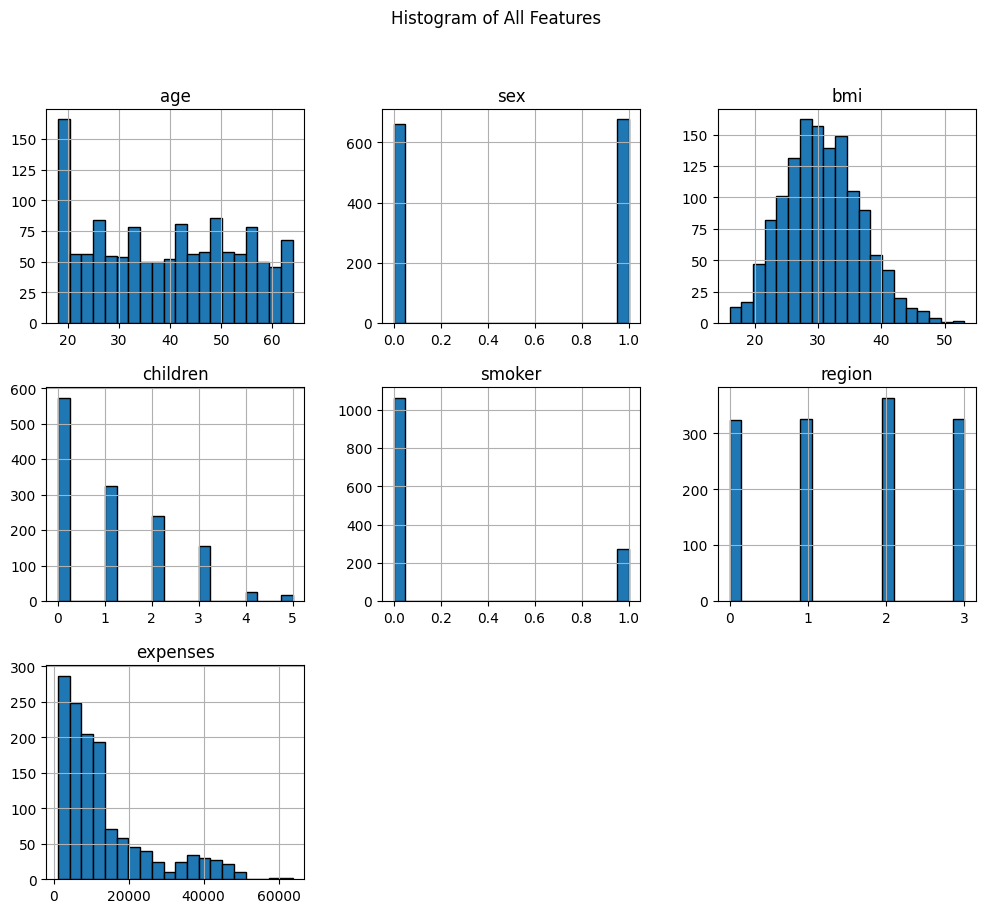

In [ ]:
df.hist(bins=20, figsize=(12,10), edgecolor='black')
plt.suptitle("Histogram of All Features")
plt.show()

# Step-2.2(create a basic countpolt for the all column)

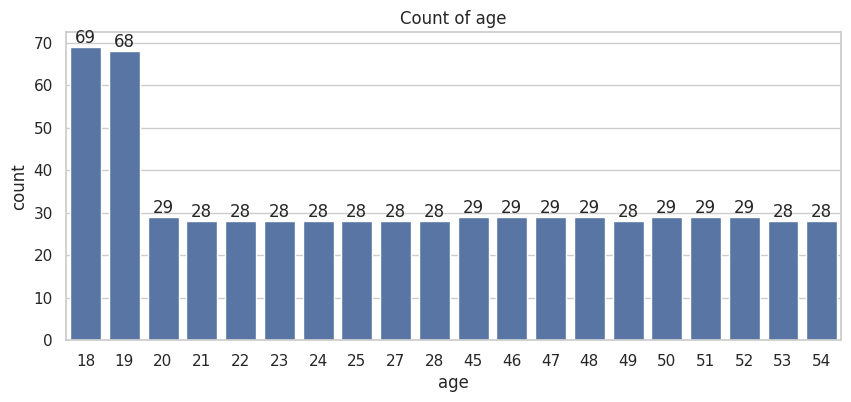

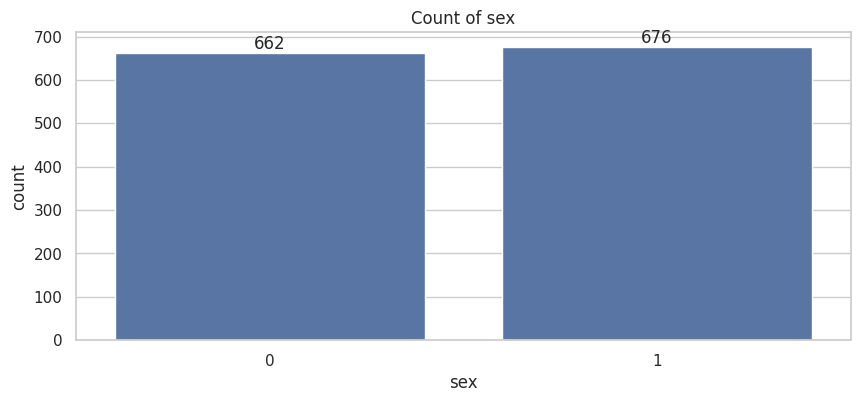

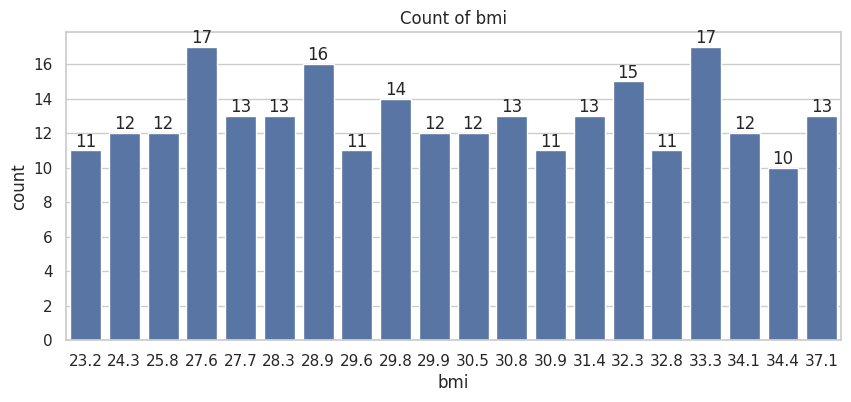

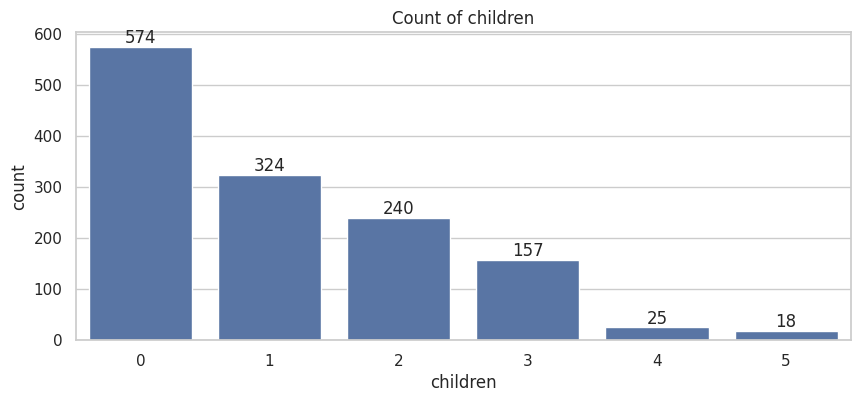

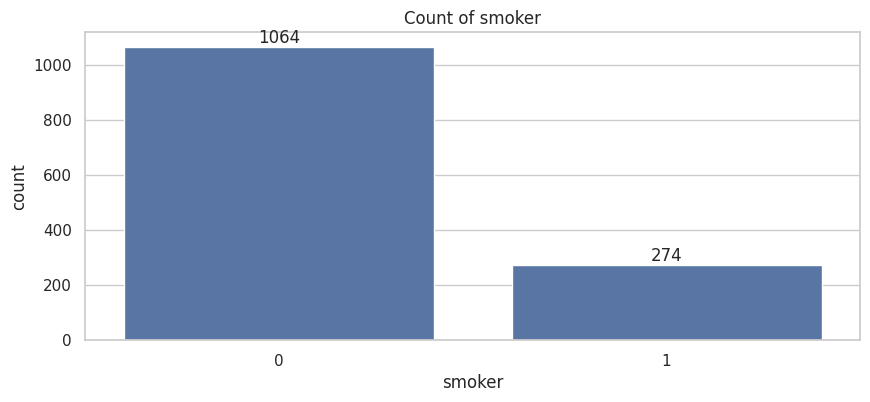

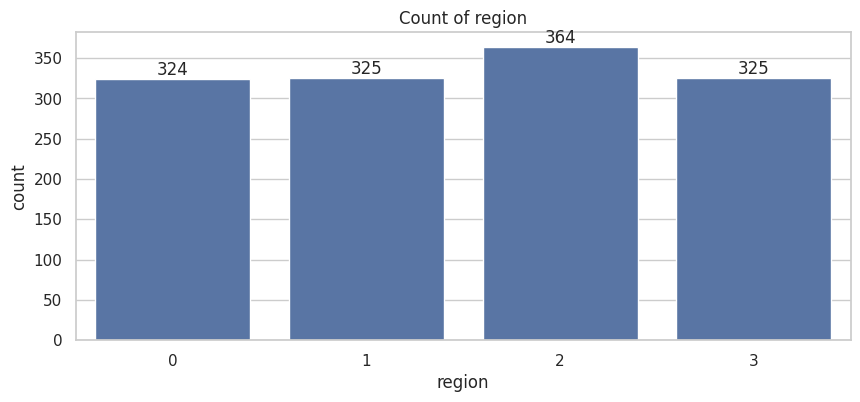

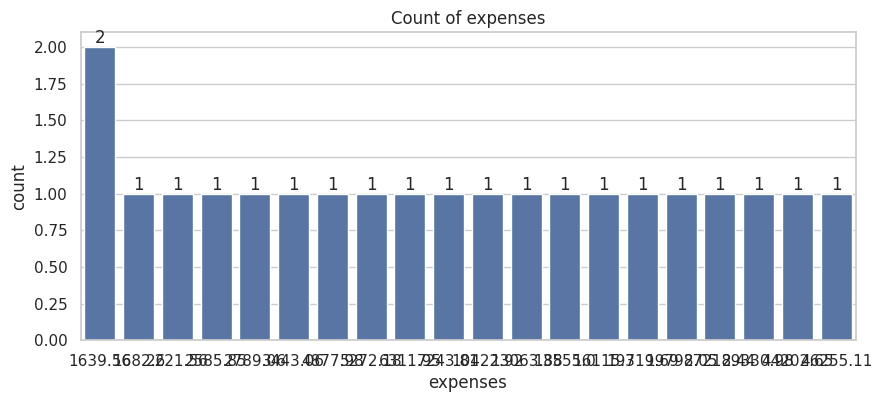

In [ ]:

sns.set(style="whitegrid")

# List of all columns
columns = ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses']


for col in columns:
    plt.figure(figsize=(10,4))

    if df[col].dtype != 'object' and df[col].nunique() > 20:
        top_values = df[col].value_counts().nlargest(20).index
        sns.countplot(x=col, data=df[df[col].isin(top_values)])
    else:
        sns.countplot(x=col, data=df)


    ax = plt.gca()
    ax.bar_label(ax.containers[0])

    plt.title(f'Count of {col}')
    plt.show()

# Step2.3((Normal-ish)
3types
1.negative
2.normal
3.negative

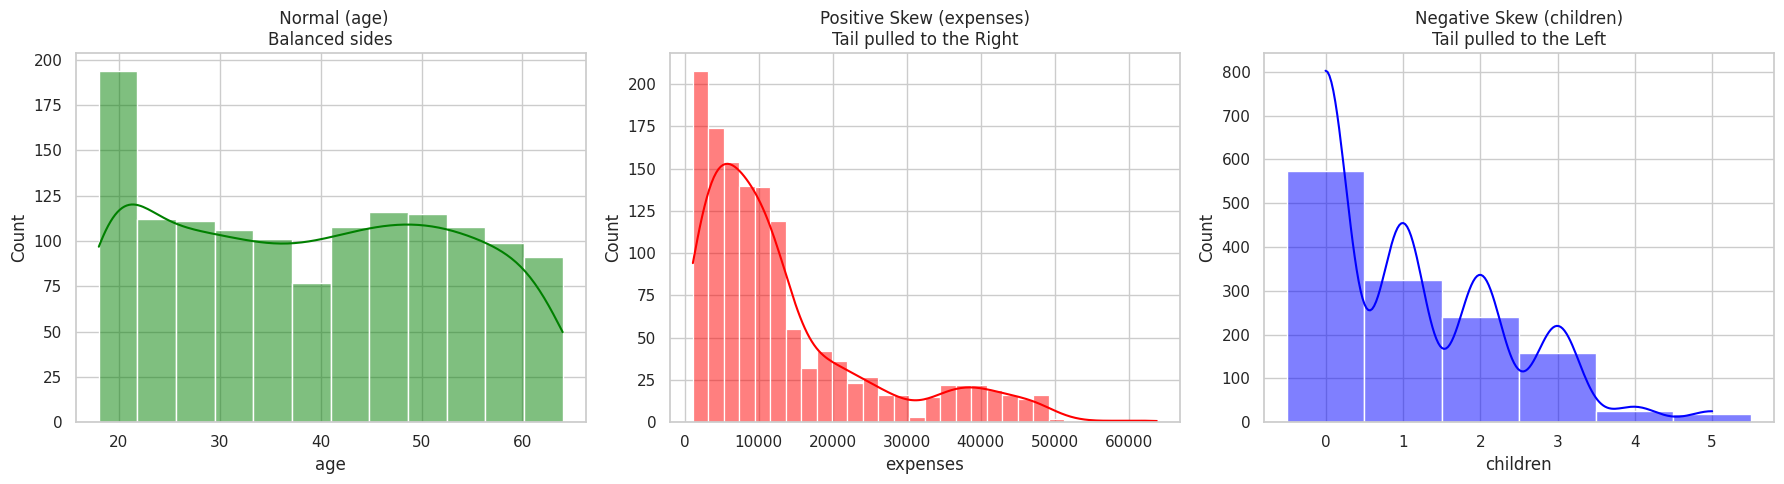

In [ ]:
plt.figure(figsize=(18, 5))

# 1. NORMAL-ISH (age)
plt.subplot(1, 3, 1)
sns.histplot(df['age'].dropna(), kde=True, color='green')
plt.title(' Normal (age)\nBalanced sides')

# 2. POSITIVE SKEW (expenses)
plt.subplot(1, 3, 2)
sns.histplot(df['expenses'], kde=True, color='red')
plt.title('Positive Skew (expenses)\nTail pulled to the Right')

# 3. NEGATIVE SKEW (children)
plt.subplot(1, 3, 3)

sns.histplot(df['children'], kde=True, color='blue', discrete=True)
plt.title('Negative Skew (children)\nTail pulled to the Left')

plt.tight_layout()
plt.show()

# Step-2.4(boxplot)making the outliers

<Axes: xlabel='bmi'>

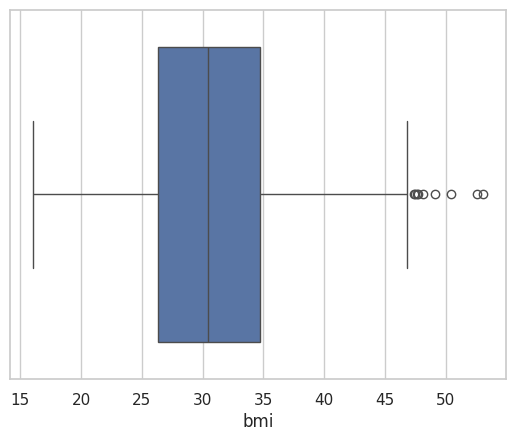

In [ ]:
sns.boxplot(x="bmi", data=df)

# Step-2.5(Regression Plot: Age vs Expenses)
# This plot shows how insurance expenses change with age, including a fitted regression line.

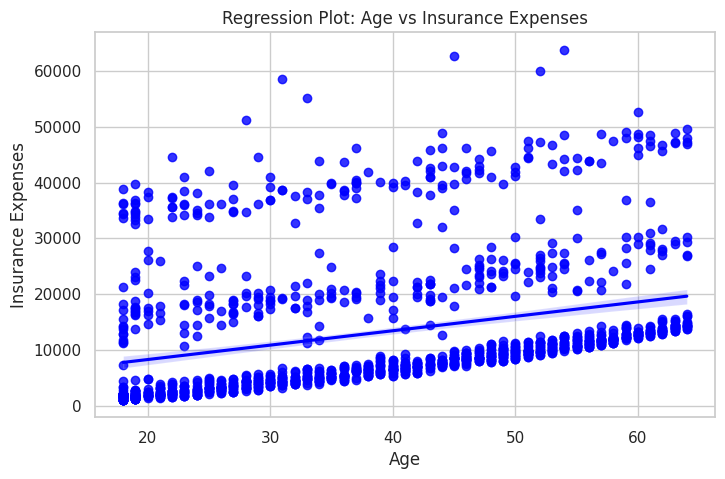

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(x='age', y='expenses', data=df, color='blue')

plt.title('Regression Plot: Age vs Insurance Expenses')
plt.xlabel('Age')
plt.ylabel('Insurance Expenses')
plt.show()

# Step-2.6(Regression Plot: BMI vs Expenses)
# This plot visualizes the linear relationship between BMI and insurance expenses.

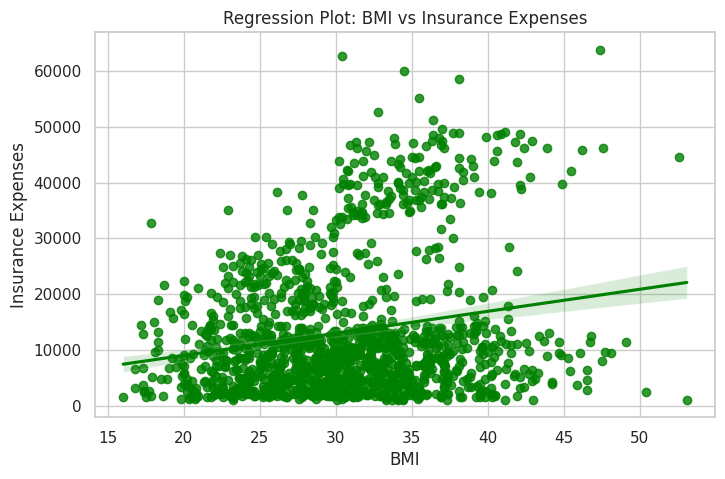

In [ ]:

plt.figure(figsize=(8,5))
sns.regplot(x='bmi', y='expenses', data=df, color='green')

plt.title('Regression Plot: BMI vs Insurance Expenses')
plt.xlabel('BMI')
plt.ylabel('Insurance Expenses')
plt.show()

# Step2.7(Pairplot  (Numeric Variables))
Pairplots display pairwise relationships between variables using scatter plots and show distributions on the diagonal.
It helps in understanding correlations and trends before applying regression.

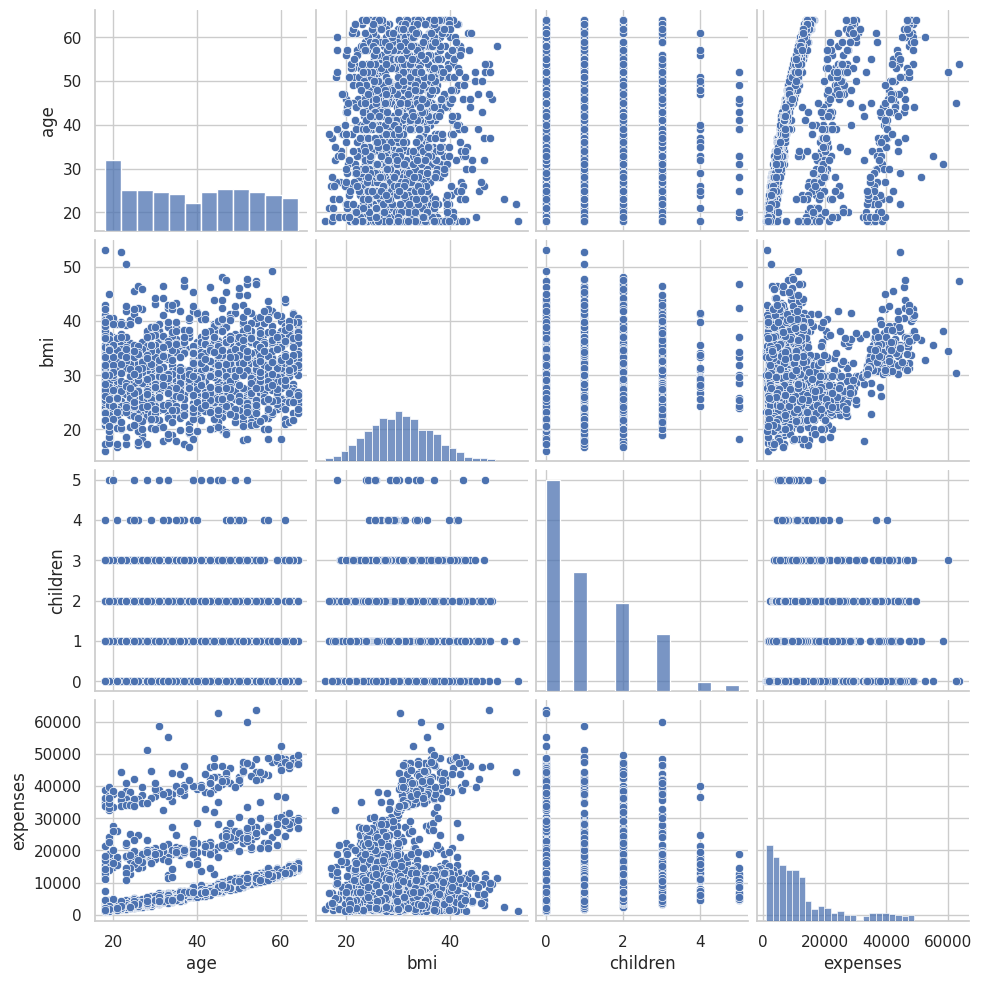

In [ ]:

df_numeric = df[['age', 'bmi', 'children', 'expenses']]

# Create pairplot
sns.pairplot(df_numeric)

plt.show()

# Step-2.5(correlation matrix)

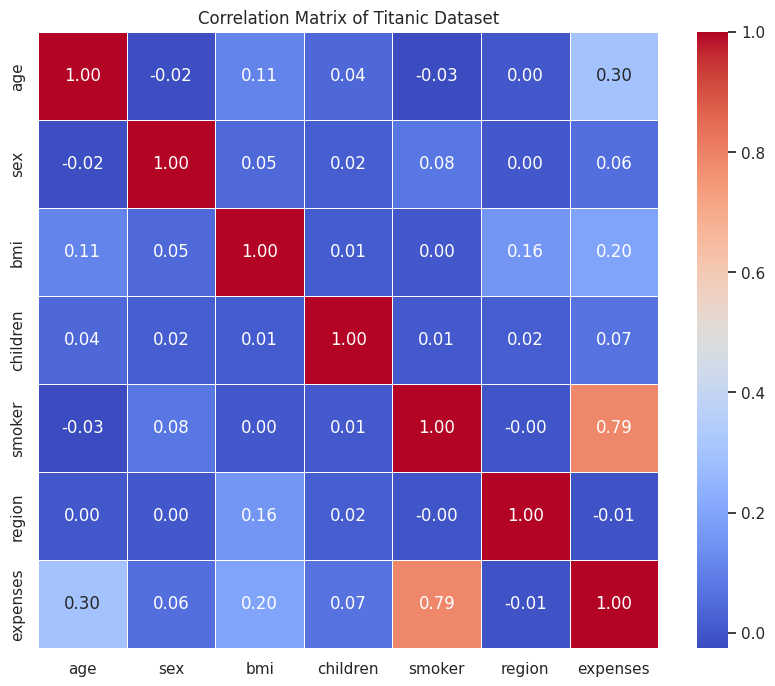

In [ ]:
df_numeric = df.select_dtypes(include=['float64', 'int64'])


corr_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Add title
plt.title('Correlation Matrix of Titanic Dataset')

# Show the plot
plt.show()

# Step2.6(confusion matrix)

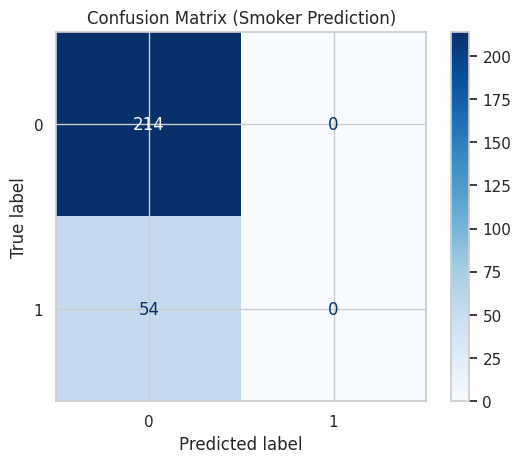

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Features (all numeric or encoded)
X = df[['age', 'bmi', 'children', 'sex', 'region']]  # predictor columns
y = df['smoker']  # target: yes/no already label encoded

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Smoker Prediction)")
plt.show()